# 2D FDTD

This notebook demonstrates **2D effective-index FDTD** simulations using `gsim.meep`.

2D simulations collapse the z-dimension, making them 10–100× faster than full 3D. They use an effective-index approximation and enforce TE polarization.

**When to use 2D:**
- Quick design-space exploration and parameter sweeps
- Verifying port connectivity and mode coupling before committing to 3D
- Components where vertical confinement is well-described by an effective index

**Requirements:**

- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from UBC PDK

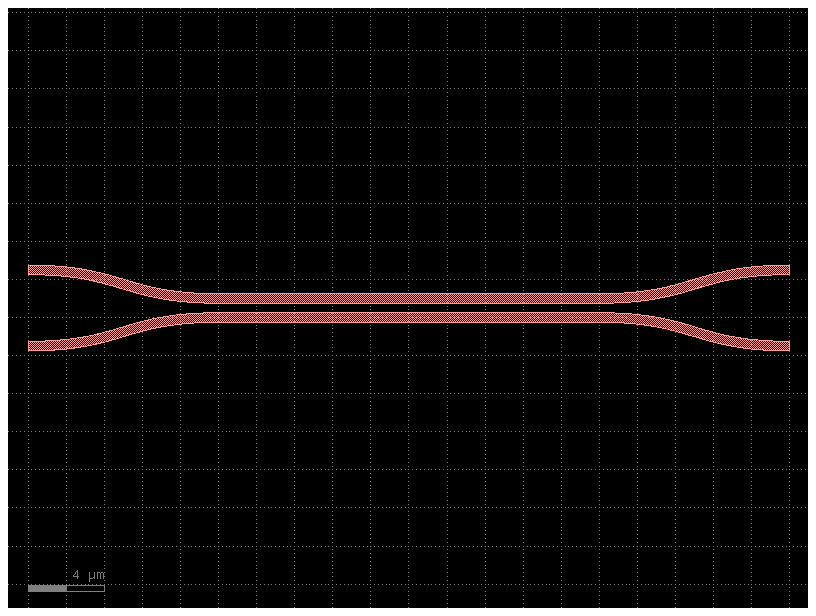

In [1]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

c = gf.components.coupler(gap=0.5)
c

### Configure 2D simulation

The only difference from a 3D simulation is `sim.solver.is_3d = False`.
This collapses the z-dimension, ignores sidewall angles, and enforces TE polarization.

In [2]:
from gsim import meep

sim = meep.Simulation()

sim.geometry(component=c)
sim.materials = {"si": 3.47, "SiO2": 1.44}
sim.source(port="o1", wavelength=1.55, wavelength_span=0.01, num_freqs=21)
sim.monitors = ["o1", "o2", "o3"]
sim.domain(pml=1.0, margin=0.5)
sim.solver(resolution=25, is_3d=False)
sim.solver.stop_when_energy_decayed()

print(sim.validate_config())

Stack validation: PASSED
Warnings:
  - No stack configured. Will use active PDK with defaults.
  - Stopping: energy_decay (dt=20.0, decay_by=0.01, cap=2000.0)


### Preview geometry

simulation.py:526: UserWarning: Material 'Aluminum' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('Aluminum', refractive_index=...) to include it.
  material_data = resolve_materials(
simulation.py:526: UserWarning: Material 'TiN' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('TiN', refractive_index=...) to include it.
  material_data = resolve_materials(
simulation.py:526: UserWarning: Material 'ge' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('ge', refractive_index=...) to include it.
  material_data = resolve_materials(
simulation.py:526: UserWarning: Material 'passive' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('passive', refractive_index=...) to include it.
  material_data = resolve_materials(


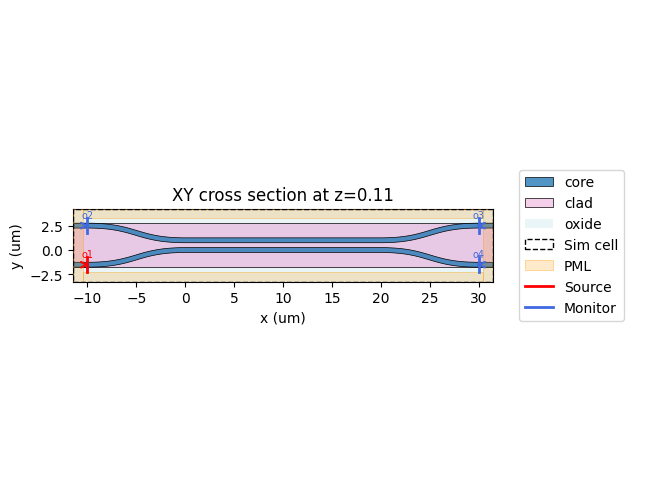

In [3]:
sim.plot_2d(slices="z")

### Run 2D simulation on cloud

In [4]:
result = sim.run()

  meep-09e41739  completed  0m 29s


Extracting results.tar.gz...
Downloaded 4 files to sim-data-meep-09e41739


In [5]:
result.plot_interactive()

In [6]:
result.plot_interactive(phase=True)